# Signal Construction for a simple trading strategy

### Step 1: Figuring out what assets we should use
### Step 2: Finding a good trading strategy to implement
### Step 3: Produce signals based on strategy
### Step 4: {Since we are doing cross sectional strategies} Rank assets


# 1. Figuring out our universe of stocks

What are some popular stocks:
* War: OIL (MPC, CVX, Exon, TPET), DEFENSE (Lockheed, Northrup, RTX, Raytheon, ONDS, LPTH, RCAT, PLTR, L3Harris, GD), SHIPPING (DHT, FRO, INSW)
* Forgotten Gems: DUOL, PEP, JNJ, IBM, NIKE, UPS, AVGO, TXN, BAC, CAT, ORCL, HOOD, COIN, TER
* METALS: CRML, USAR, 
* VALUE: APLD, NBIS, IREN, ACHR, ZETA, HIMS, GLXY, CRCL, CRWV, MRNA, NVO, ASTS, AMPX, SES AI, OUST, PYPL, SOFI, 

##### I think my universe will be Forgotten GEMS, GOOD diversity and potential as well

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import datetime
import pandas as pd

univ = ['DUOL', 'PEP', 'KO', 'JNJ', 'IBM', 'MCD', 'WMT', 'PG', 'DIS', 'VZ', 'TMUS', 'COST', 'NKE', 'UPS', 'AVGO', 'TXN', 
        'BAC', 'CAT', 'ORCL', 'HOOD', 'COIN', 'TER', 'PYPL', 'ADBE', 'CRM', 'INTU', 'NFLX', 'AMZN', 'GOOGL', 'META', 'AAPL', 'INTC']


# 2. What strategy to use

* What do all these stocks have in common and or are they different?
- Common: 
    * They are more or less companies that have around for a long time and have a proved track record
    * They have revenue and are mostly all profitable, 
    * They are more or less trying to attract new investors by doing something new, changing something
    * Some seem to have momentum behind then and some seem to have reversal
- Difference
    * They are all from different sectors and have varying impact on the whole market
    * Some are big players and some are small
    * Some have been for a very long time and some are companies that have burst of momentum and slowly dying
    * Lot more....


* Cross Sectional Metrics I like for this universe of stocks:
    - Momentum
        * 2 years
    - Reversal
        * 6 months
        * 3 months
        * 1 month
    - Earnings
        * Past 10 earnings

* Ranking Formula: 
    * Each stock gets individual pscore:
    * Weights on 3 metrics (Should add up to 100)
        - Momentum: 35
        - Reversal: 50
        - Earnings: 15
    * pscore = 35 * Momentum Score + 50 * Reversal SCore + 15 * Earnings Score

##### Step 1: Get respective score
##### Step 2: Rank stock in universe based on their pscore
##### Step 3: Strat: Long upper 60% and short rest

### Strategy: Based on rankings, Long upper 60% and short rest (Numbers subject to change, who knowns)


In [2]:
# Making a momentum matrix for the universe of stocks. We will use the past 2 year prices data and calculate momentum score for each 
# stock. We will exclude the most recent month to avoid look-ahead bias.
from matplotlib import ticker


def get_momentum_scores(tickers, start_date, end_date):
    momentum_scores = {}
    
    for ticker in tickers:
        data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
        if not data.empty and len(data) >= 2:
            # Calculate momentum score as the percentage change over the period
            # use positional indexing, not label indexing
            first = data['Adj Close'].iloc[0].item()  # get the first value as a scalar
            last  = data['Adj Close'].iloc[-1].item()  # get the last value as a scalar
            momentum_score = float((last - first) / first)  # convert to float
            momentum_scores[ticker] = momentum_score
            
    return momentum_scores

# Define the date range for the past 2 years, excluding the most recent month
end_date = datetime.datetime.now() - pd.DateOffset(months=1)
start_date = end_date - pd.DateOffset(years=2)
momentum_scores = get_momentum_scores(univ, start_date, end_date)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [3]:
momentum_scores

{'DUOL': -0.3611934028223857,
 'PEP': 0.04890877812555918,
 'KO': 0.3896374978359632,
 'JNJ': 0.5995672271010355,
 'IBM': 0.6800083526720102,
 'MCD': 0.19110138675636595,
 'WMT': 1.2912282810864821,
 'PG': 0.050475376902399456,
 'DIS': 0.07858748020759235,
 'VZ': 0.30713172830549346,
 'TMUS': 0.2921352604244466,
 'COST': 0.40518564960934716,
 'NKE': -0.3638659949411765,
 'UPS': -0.1052023263512625,
 'AVGO': 1.5971129850837797,
 'TXN': 0.4900453873086885,
 'BAC': 0.7446401360999924,
 'CAT': 1.1628650301369627,
 'ORCL': 0.2086029296113868,
 'HOOD': 5.742115223146083,
 'COIN': 0.21980126889077622,
 'TER': 1.7972314867785344,
 'PYPL': -0.3722768872871113,
 'ADBE': -0.5562967220923053,
 'CRM': -0.3272987003387423,
 'INTU': -0.30655081810291057,
 'NFLX': 0.45481040739535744,
 'AMZN': 0.31652385738593075,
 'GOOGL': 1.3161196971956866,
 'META': 0.4841916930730915,
 'AAPL': 0.4712923788515974,
 'INTC': 0.14045850377841795}

In [4]:
# Display the momentum_scores dictionary (tickers as keys, momentum scores as values)
print("Momentum Scores Dictionary:")
print(momentum_scores)
# print("\n" + "="*50 + "\n")

# Convert the momentum_scores dict into a dataframe with tickers as the index
momentum_scores_df = pd.DataFrame.from_dict(
    momentum_scores,
    orient="index",
    columns=["Momentum Score"],
)
momentum_scores_df.index.name = "Ticker"

print("Momentum Scores DataFrame:")
momentum_scores_df

Momentum Scores Dictionary:
{'DUOL': -0.3611934028223857, 'PEP': 0.04890877812555918, 'KO': 0.3896374978359632, 'JNJ': 0.5995672271010355, 'IBM': 0.6800083526720102, 'MCD': 0.19110138675636595, 'WMT': 1.2912282810864821, 'PG': 0.050475376902399456, 'DIS': 0.07858748020759235, 'VZ': 0.30713172830549346, 'TMUS': 0.2921352604244466, 'COST': 0.40518564960934716, 'NKE': -0.3638659949411765, 'UPS': -0.1052023263512625, 'AVGO': 1.5971129850837797, 'TXN': 0.4900453873086885, 'BAC': 0.7446401360999924, 'CAT': 1.1628650301369627, 'ORCL': 0.2086029296113868, 'HOOD': 5.742115223146083, 'COIN': 0.21980126889077622, 'TER': 1.7972314867785344, 'PYPL': -0.3722768872871113, 'ADBE': -0.5562967220923053, 'CRM': -0.3272987003387423, 'INTU': -0.30655081810291057, 'NFLX': 0.45481040739535744, 'AMZN': 0.31652385738593075, 'GOOGL': 1.3161196971956866, 'META': 0.4841916930730915, 'AAPL': 0.4712923788515974, 'INTC': 0.14045850377841795}
Momentum Scores DataFrame:


,Momentum Score
Ticker,
DUOL,-0.361193
PEP,0.048909
KO,0.389637
JNJ,0.599567
IBM,0.680008
MCD,0.191101
WMT,1.291228
PG,0.050475
DIS,0.078587


In [22]:
# Making a reversal matrix for the universe of stocks. We wil use data from past 3, 2, 1 months and calculate reversal score for each stock.
def get_reversal_scores(tickers, start_date, end_date):
    reversal_scores = {}
    
    for ticker in tickers:
        data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
        if not data.empty and len(data) >= 2:
            # Calculate reversal score as the percentage change over the period
            first = float(data['Adj Close'].iloc[0])
            last = float(data['Adj Close'].iloc[-1])
            reversal_score = (last - first) / first  # now just a float
            reversal_scores[ticker] = reversal_score
            
    return reversal_scores

# first define the date range for the past 3 months
end_date = datetime.datetime.now() - pd.DateOffset(days=1)
start_date = end_date - pd.DateOffset(months=3)
reversal_scores_3m = get_reversal_scores(univ, start_date, end_date)
# then define the date range for the past 2 months
end_date = datetime.datetime.now() - pd.DateOffset(days=1)
start_date = end_date - pd.DateOffset(months=2)
reversal_scores_2m = get_reversal_scores(univ, start_date, end_date)
# then define the date range for the past 1 month
end_date = datetime.datetime.now() - pd.DateOffset(days=1)
start_date = end_date - pd.DateOffset(months=1)
reversal_scores_1m = get_reversal_scores(univ, start_date, end_date)
# Combine the reversal scores into a single score by averaging the 3, 2, and 1 month scores
combined_reversal_scores = {}
for ticker in univ:
    score_3m = reversal_scores_3m.get(ticker, 0)
    score_2m = reversal_scores_2m.get(ticker, 0)
    score_1m = reversal_scores_1m.get(ticker, 0)
    combined_score = -(score_3m + score_2m + score_1m) / 3
    combined_reversal_scores[ticker] = combined_score

# Display the combined reversal scores
print("Combined Reversal Scores Dictionary:")
print(combined_reversal_scores)
print("\n" + "="*50 + "\n")
# Convert the combined_reversal_scores dict into a dataframe with tickers as the index
combined_reversal_scores_df = pd.DataFrame.from_dict(
    combined_reversal_scores,
    orient="index",
    columns=["Combined Reversal Score"],
)
combined_reversal_scores_df.index.name = "Ticker"
print("Combined Reversal Scores DataFrame:")
combined_reversal_scores_df

[*********************100%***********************]  1 of 1 completed
C:\Users\mroha\AppData\Local\Temp\ipykernel_16136\1626680188.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  first = float(data['Adj Close'].iloc[0])
C:\Users\mroha\AppData\Local\Temp\ipykernel_16136\1626680188.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last = float(data['Adj Close'].iloc[-1])
[*********************100%***********************]  1 of 1 completed
C:\Users\mroha\AppData\Local\Temp\ipykernel_16136\1626680188.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  first = float(data['Adj Close'].iloc[0])
C:\Users\mroha\AppData\Local\Temp\ipykernel_16136\1626680188.py:10: FutureWarning: Calling float on a 

Combined Reversal Scores Dictionary:
{'DUOL': 0.3860145012872591, 'PEP': -0.09343500373746304, 'KO': -0.0866785346694137, 'JNJ': -0.15510371321902341, 'IBM': 0.15440903260119032, 'MCD': -0.07187137660492372, 'WMT': -0.08447276627475642, 'PG': -0.08171396883816198, 'DIS': 0.04330769089849956, 'VZ': -0.21041048762422365, 'TMUS': -0.08196387282129154, 'COST': -0.09749272973679723, 'NKE': 0.08250177614707928, 'UPS': -0.08024949698347107, 'AVGO': 0.0791817382890307, 'TXN': -0.051566656860287906, 'BAC': 0.08931620327034907, 'CAT': -0.16211198602037244, 'ORCL': 0.1293911568179979, 'HOOD': 0.1929219556443603, 'COIN': -0.00801065212416032, 'TER': -0.345975729503699, 'PYPL': 0.09365793258773301, 'ADBE': 0.12454675633930318, 'CRM': 0.16266284193179065, 'INTU': 0.2125681396609346, 'NFLX': -0.09431452288728083, 'AMZN': 0.050471688378221545, 'GOOGL': 0.06103367433447641, 'META': -0.0007430670410906662, 'AAPL': 0.04063366149850312, 'INTC': -0.06776459960625016}


Combined Reversal Scores DataFrame:



C:\Users\mroha\AppData\Local\Temp\ipykernel_16136\1626680188.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  first = float(data['Adj Close'].iloc[0])
C:\Users\mroha\AppData\Local\Temp\ipykernel_16136\1626680188.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last = float(data['Adj Close'].iloc[-1])


,Combined Reversal Score
Ticker,
DUOL,0.386015
PEP,-0.093435
KO,-0.086679
JNJ,-0.155104
IBM,0.154409
MCD,-0.071871
WMT,-0.084473
PG,-0.081714
DIS,0.043308


In [23]:
# Making a earnings score matrix for the universe of stocks. We will use the past 8 quarters earnings data and calculate earnings score for each stock.
def get_earnings_scores(tickers):
    earnings_scores = {}
    
    for ticker in tickers:
        stock = yf.Ticker(ticker)
        earnings = stock.get_earnings_dates(limit=8)  # Get the past 8 quarters of earnings data
        if not earnings.empty and len(earnings) >= 8:
            # Calculate earnings score as the average percentage change in earnings over the past 4 quarters
            earnings["surprise"] = (
            (earnings["Reported EPS"] - earnings["EPS Estimate"]) /
                earnings["EPS Estimate"].abs()
            )
            average_surprise = earnings['surprise'].mean()
            earnings_scores[ticker] = average_surprise
            
    return earnings_scores

earnings_scores = get_earnings_scores(univ)
# Display the earnings scores
print("Earnings Scores Dictionary:")
print(earnings_scores)
print("\n" + "="*50 + "\n")
# Convert the earnings_scores dict into a dataframe with tickers as the index
earnings_scores_df = pd.DataFrame.from_dict(
    earnings_scores,
    orient="index",
    columns=["Earnings Score"],
)
earnings_scores_df.index.name = "Ticker"
print("Earnings Scores DataFrame:")
earnings_scores_df

Earnings Scores Dictionary:
{'DUOL': np.float64(0.6023560181648416), 'PEP': np.float64(0.029784703445320727), 'KO': np.float64(0.03778201372025186), 'JNJ': np.float64(0.04246527132311062), 'IBM': np.float64(0.07482521305301573), 'MCD': np.float64(0.011805827361566447), 'WMT': np.float64(0.052020747835443665), 'PG': np.float64(0.039899504819053806), 'DIS': np.float64(0.16147272911254365), 'VZ': np.float64(0.014008579850510553), 'TMUS': np.float64(0.04801599807255885), 'COST': np.float64(0.023709448852088463), 'NKE': np.float64(0.3251710895393712), 'UPS': np.float64(0.0430851546273665), 'AVGO': np.float64(0.033621164691496855), 'TXN': np.float64(0.07701881933984366), 'BAC': np.float64(0.09756097560975618), 'CAT': np.float64(0.056179391089961325), 'ORCL': np.float64(0.01345793240004915), 'HOOD': np.float64(1.123015873015873), 'COIN': np.float64(15.2009714036601), 'TER': np.float64(0.19708222263878783), 'PYPL': np.float64(0.11789344287011887), 'ADBE': np.float64(0.0251008785563138), 'CRM':

,Earnings Score
Ticker,
DUOL,0.602356
PEP,0.029785
KO,0.037782
JNJ,0.042465
IBM,0.074825
MCD,0.011806
WMT,0.052021
PG,0.039900
DIS,0.161473


In [ ]:
# Making a combined score matrix for the universe of stocks. We will combine the momentum, reversal, and earnings scores into a single score for each stock.
combined_scores_df = momentum_scores_df.join(combined_reversal_scores_df).join(earnings_scores_df)
# Fill any missing values with 0 (if a stock is missing a score, we will treat it as 0 for that score)
combined_scores_df = combined_scores_df.fillna(0)
print("Combined Scores DataFrame:")
combined_scores_df

Combined Scores DataFrame:


,Momentum Score,Combined Reversal Score,Earnings Score
Ticker,,,
DUOL,-0.361193,0.386015,0.602356
PEP,0.048909,-0.093435,0.029785
KO,0.389638,-0.086679,0.037782
JNJ,0.599567,-0.155104,0.042465
IBM,0.680008,0.154409,0.074825
MCD,0.191101,-0.071871,0.011806
WMT,1.291228,-0.084473,0.052021
PG,0.050475,-0.081714,0.039900
DIS,0.078587,0.043308,0.161473


Combined Scores DataFrame with Pscore:
Sorted Pscore Dictionary:


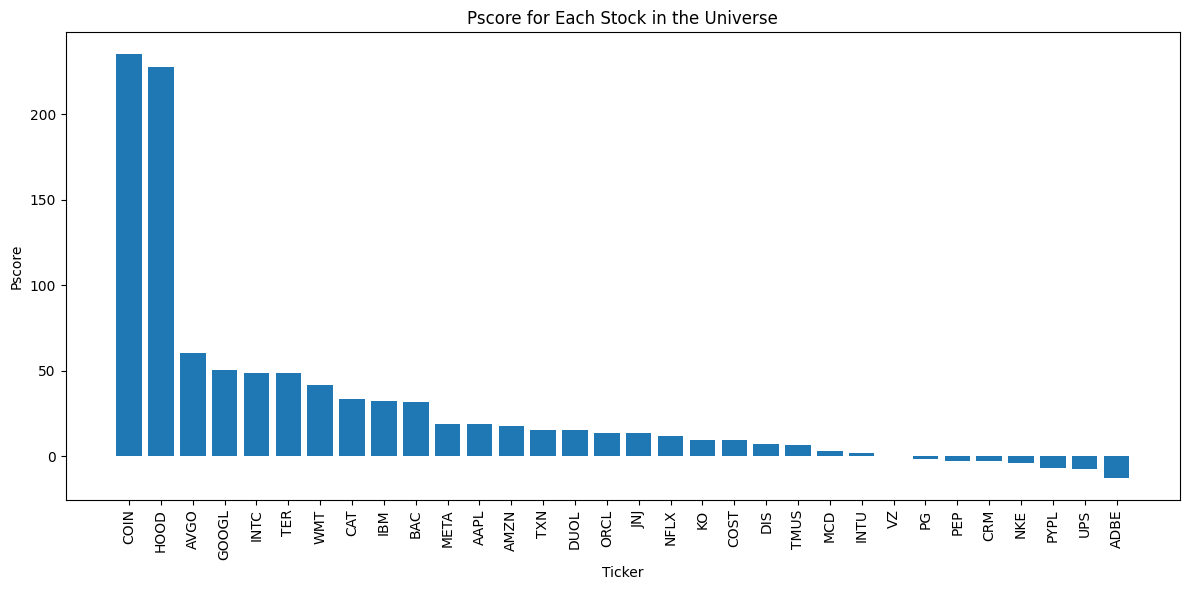

In [25]:
# add another columns for pscore according to this formula: pscore = 35 * momentum_score + 50 * combined_reversal_score + 15 * earnings_score
combined_scores_df["Pscore"] = (
    35 * combined_scores_df["Momentum Score"] +
    50 * combined_scores_df["Combined Reversal Score"] +
    15 * combined_scores_df["Earnings Score"]
)
print("Combined Scores DataFrame with Pscore:")
combined_scores_df

# make a dictionary of tickers and their corresponding pscores
pscore_dict = combined_scores_df["Pscore"].to_dict()
# Sort the dictionary by pscore in descending order
sorted_pscore_dict = dict(sorted(pscore_dict.items(), key=lambda item: item[1], reverse=True))
print("Sorted Pscore Dictionary:")

# make a bar chart of all the stocks and their corresponding pscores
plt.figure(figsize=(12, 6))
plt.bar(sorted_pscore_dict.keys(), sorted_pscore_dict.values())
plt.xlabel("Ticker")
plt.ylabel("Pscore")
plt.title("Pscore for Each Stock in the Universe")
plt.xticks(rotation=90)
plt.tight_layout()

# 3. Signal Construction 

* Long Stock (Signal = 1) if above upper_threshold
* Don't do anything if between upper_threshold and lower_threshold
* Short Stock (Signal = -1) if below lower_threshold

* How to determine upper and lower threshold
    - Normal Distribution graph showcasing where stock fall
    - Deciding randomly 

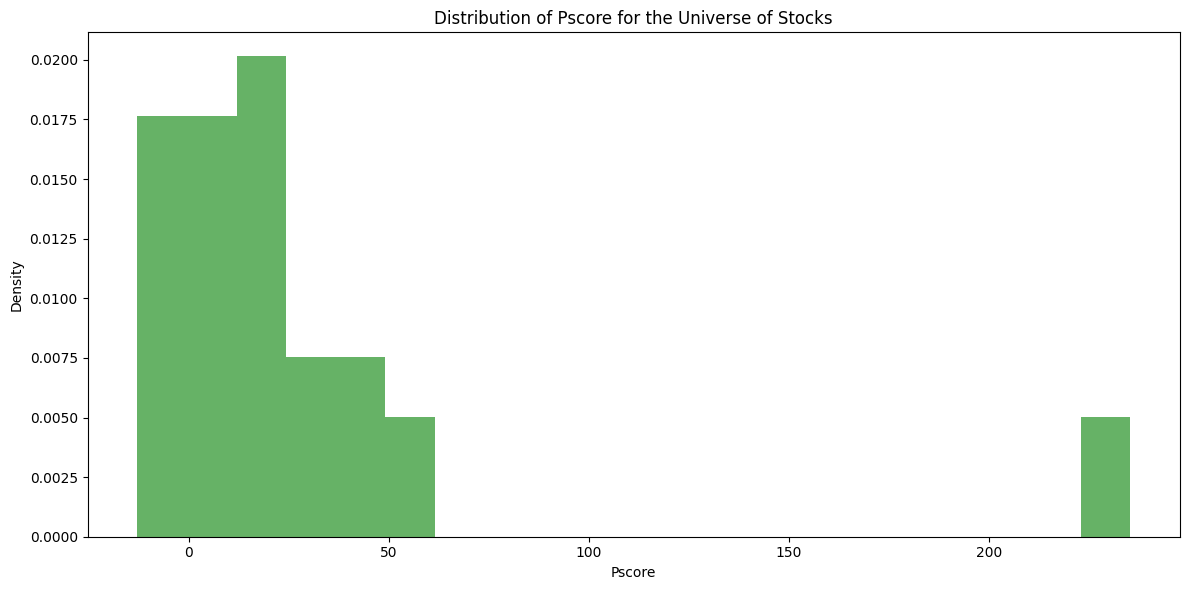

In [26]:
# making a normal distribution curve of the pscores
plt.figure(figsize=(12, 6))
plt.hist(combined_scores_df["Pscore"], bins=20, density=True, alpha=0.6, color='g')
plt.xlabel("Pscore")
plt.ylabel("Density")
plt.title("Distribution of Pscore for the Universe of Stocks")
plt.tight_layout()

From this graph, we see see upper_threshold being around 30-40, so lets pick 

Upper_threshold = 35

Lower_threshold = 10


In [34]:
upper_threshold = combined_scores_df["Pscore"].quantile(0.78)
lower_threshold = combined_scores_df["Pscore"].quantile(0.42)
print(f"Upper Threshold (60th percentile): {upper_threshold}")
print(f"Lower Threshold (40th percentile): {lower_threshold}")

Upper Threshold (60th percentile): 34.933587776278316
Lower Threshold (40th percentile): 9.915878196305826


I didn't know I could do quantiles, though it was cool and tweaked the percentages to get my desired thresholds

In [36]:
# make a signal matrix for the universe of stocks. We will assign a signal of 1 to stocks with a pscore above the upper threshold, a signal of -1 to stocks with a pscore below the lower threshold, and a signal of 0 to stocks with a pscore between the two thresholds.
def assign_signal(pscore, upper_threshold, lower_threshold):
    if pscore > upper_threshold:
        return 1
    elif pscore < lower_threshold:
        return -1
    else:
        return 0

signals_df = pd.DataFrame({
    "Pscore": combined_scores_df["Pscore"],
    "Signal": combined_scores_df["Pscore"].apply(lambda x: assign_signal(x, upper_threshold, lower_threshold))
})
print("Signals DataFrame:")
signals_df

Signals DataFrame:


,Pscore,Signal
Ticker,,
DUOL,15.694296,0
PEP,-2.513169,-1
KO,9.870119,-1
JNJ,13.866635,0
IBM,32.643122,0
MCD,3.272062,-1
WMT,41.749668,1
PG,-1.720568,-1
DIS,7.338037,-1
